In [15]:
import os
import gzip
import struct
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# No modifiques esta función
def read_idx(filename):
    with gzip.open(filename, 'rb') as f:
        zero, data_type, dims = struct.unpack('>HBB', f.read(4))
        shape = tuple(struct.unpack('>I', f.read(4))[0] for d in range(dims))
        return np.frombuffer(f.read(), dtype=np.uint8).reshape(shape)
        
def load_data(path_imgs, path_labels):
    X = read_idx(path_imgs)
    y = read_idx(path_labels)
    
    X= X.astype('float32')
    X /= 255
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)
    
    return X_train, y_train, X_test, y_test


Dataset shape: 48000 [n_images,hight,width]


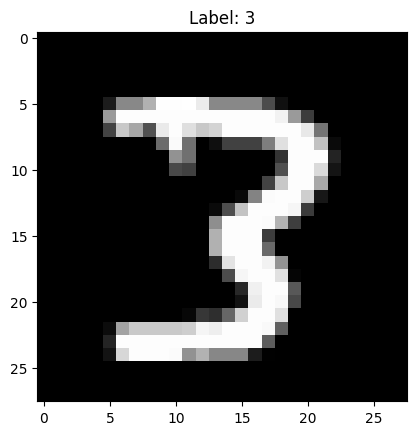

In [8]:
imgs = '../data/train-images-idx3-ubyte.gz'
labels = '../data/train-labels-idx1-ubyte.gz'  

X_train, y_train, X_test, y_test = load_data(imgs, labels)

print('Dataset shape:', X_train.shape[0], "[n_images,hight,width]")
plt.imshow(X_train[0].reshape(28, 28), cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.show()

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam

def create_model(input_shape, num_classes):
    model = Sequential()
    model.add(Flatten(input_shape=input_shape))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(16, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))  # Capa de salida
    
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['acc'])
    
    return model

In [18]:
def train_model(model, train_data, test_data, batch_size=32, epochs=5, verbose=2):
    history = model.fit(train_data[0], train_data[1],
                    validation_data=test_data,
                    batch_size=batch_size, 
                    epochs=epochs,
                    shuffle=True,
                    verbose=verbose)
    return history

imgs = '../data/train-images-idx3-ubyte.gz'
labels = '../data/train-labels-idx1-ubyte.gz'  

X_train, y_train, X_test, y_test = load_data(imgs, labels)
    
model = create_model((28, 28), 10)
model_trained = train_model(model, 
                        (X_train, y_train),
                        (X_test, y_test),
                        batch_size=32,
                        epochs=10,
                        verbose=1)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 645us/step - acc: 0.8885 - loss: 0.3578 - val_acc: 0.9424 - val_loss: 0.1929
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 616us/step - acc: 0.9544 - loss: 0.1545 - val_acc: 0.9553 - val_loss: 0.1520
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 581us/step - acc: 0.9652 - loss: 0.1157 - val_acc: 0.9595 - val_loss: 0.1287
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 582us/step - acc: 0.9710 - loss: 0.0940 - val_acc: 0.9619 - val_loss: 0.1221
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 597us/step - acc: 0.9776 - loss: 0.0750 - val_acc: 0.9615 - val_loss: 0.1266
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 590us/step - acc: 0.9801 - loss: 0.0638 - val_acc: 0.9687 - val_loss: 0.1080
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 584us/step - acc: 0.9827 - loss: 0.0554 - val_acc: 0.9648 - val_loss: 0.1257
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 587us/step - acc: 0.9844 - loss: 0.0486 - val_acc: 0.9648 - val_loss: 0.1251
Epoch 9/10
1500/1500 ━━━